# **Máster en Behavioral Data Science** - Instituto de Formación Continua (IL3) - Universitat de Barcelona
## **Módulo 7: Aprendizaje Automático - Reto I**
Autor: **Meysam Madadi**

Colaborador: **Julio C. S. Jacques Junior**

---

# Antes de empezar
- Cada vez que se requiera una respuesta (o fragmento de código) habrá un texto en rojo o un comentario en una celda de código, donde deberás (hacer doble clic en la celda y) proporcionar la información requerida.
- Se recomienda crear una copia de este archivo para que puedas practicar todo lo que necesites antes de entregar la tarea.
- **No cambie la estructura ni el formato** de este archivo.
- Cuando hayas terminado, puedes hacer clic en "File", "Download", **"Dowload .ipynb"**.
- Nombre el archivo descargado como "**Nombre_Apellido_Reto_1.ipynb**" antes de enviarlo.

---
# Información personal
<font color='red'>(Haga doble clic en esta celda e informe...)</font>

<font color='red'>**Nombre completo:** GRUPO E -- Lluís Baldirà Jorro,
Maria Barraza Diaz,
Max Comerma i Martos,
Ana Gabriela Dos Santos Figueira</font>

---

# **Reto 1:** Técnicas de aprendizaje automático no supervisado para datos relacionados con la personalidad.
* El conjunto de datos proporcionado es una versión modificada de la base de datos “OCEAN Five Factor Personality Test Responses” (https://www.kaggle.com/datasets/lucasgreenwell/ocean-five-factor-personality-test-responses), denominado en este reto como “**data4.csv**”. También proporcionamos los datos originales (“**data4_original.csv**”).

# Descargando los datos
- Los datos descargados se pueden encontrar usando la interfaz de Colab (en la parte izquierda de esta ventana, en "Files")
- Al ejecutar el código en el siguiente bloque, se imprimirá en pantalla una matriz con tamaño **(19719, 55)** almacenada en "**datos**", y los nombres de los atributos (o características) en las columnas almacenados en "**datacolumns**".

In [1]:
# descargando los datos (originales y modificados)
!wget http://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4_original.csv
!wget http://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4.csv

--2024-06-24 21:33:57--  http://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4_original.csv
Resolving data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)... 158.109.8.102
Connecting to data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)|158.109.8.102|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2193877 (2.1M) [application/octet-stream]
Saving to: ‘data4_original.csv’

data4_original.csv  100%[===================>]   2.09M   534KB/s    in 4.3s    

2024-06-24 21:34:02 (496 KB/s) - ‘data4_original.csv’ saved [2193877/2193877]

--2024-06-24 21:34:02--  http://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4.csv
Resolving data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)... 158.109.8.102
Connecting to data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)|158.109.8.102|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2193651 (2.1M) [application/octet-stream

In [2]:
import numpy as np

def load_data(file_name):
    data = []
    with open(file_name, 'r') as fid:
        lines = fid.readlines()

        # la primera fila contiene el nombre de las columnas
        datacolumns = lines[0][:-1].split(',')

        for i in range(1, len(lines)):
            l = lines[i][:-1].split(',')
            data.append(l)
    data = np.array(data, dtype=np.float32)

    return data, datacolumns

# la siguiente línea carga los datos (modificados) que acabamos de descargar
data, datacolumns = load_data('data4.csv')

# imprimiendo el tamaño de la matriz
print(data.shape)

# imprimiendo las columnas (atributos)
print(datacolumns)

(19719, 55)
['race', 'age', 'engnat', 'gender', 'hand', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10']


# Jugando con índices en Python y calculando algunas estadísticas
El siguiente bloque ilustra cómo podemos inspeccionar los datos.
- Primero, se imprimen los atributos almacenados en "datacolumns", del índice 5 al 15, es decir, de "E1" a "E10" según nuestra estructura de datos. Tenga en cuenta que en python el índice del primer elemento de un vector es 0 y no 1.
- Luego, se imprimen los valores de las preguntas (del índice 5 al 15) de las primeras 3 muestras contenidas en nuestra estructura de datos ("**datos**"), es decir, del índice 0 al "3" (que no incluye el elemento con índice = 3).
- Estos son algunos ejemplos que podemos utilizar para seleccionar parte de los datos que se imprimirán, visualizarán o procesarán. Manejar cómo extraer la información requerida de toda la estructura de datos es un paso básico pero fundamental.
- Finalmente, las últimas instrucciones imprimen el valor promedio y la varianza de las respuestas asociadas a la pregunta "E1" (índice 5) para las mismas muestras, utilizando la librería "numpy". Numpy es una librería muy poderosa. Consulte su documentación para ver qué más podrías hacer: (https://numpy.org/doc/stable/)
- Siéntase libre para cambiar los valores de los índices para ver qué se obtiene como resultado (esta celda no se utilizará en la evaluación). Puedes simplemente copiar y pegar para mantener el código original como copia de seguridad. Es importante que te acostumbres al lenguaje para ver qué puedes hacer.




In [3]:
# imprimiendo algunos valores almacenados en "datacolumns"
print(datacolumns[5:15])
print("---")

# imprimiendo los valores de algunas muestras almacenadas en"data"
print(data[0:3,5:15])

print("---")
# calculando e imprimiendo el valor promedio de algunas muestras y atributos
print("Valor promedio = ", np.mean(data[0:3,5]))

# calculando e imprimiendo la varianza de algunas muestras y atributos
print("Varianza = ", np.var(data[0:3,5]))

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']
---
[[4. 2. 5. 2. 5. 1. 4. 3. 5. 1.]
 [2. 2. 3. 3. 3. 3. 1. 5. 1. 5.]
 [5. 1. 1. 4. 5. 1. 1. 5. 5. 1.]]
---
Valor promedio =  3.6666667
Varianza =  1.5555557


---
# **TAREA 1:** Visualizando los datos con diagramas de caja (box plot) e histograma

- Primero, queremos ver cómo se ven los datos al visualizar las distribuciones de frecuencia en diferentes tipos de gráficos: gráficos de caja e histograma. El diagrama de caja muestra la media y la varianza junto con los valores atípicos (*outliers*), mientras que el histograma muestra el número de muestras que pertenecen a diferentes rangos (distribución de datos) dado un número predefinido de "bins".

- En la siguiente celda, tenemos el código para dibujar la distribución de frecuencias como un diagrama de caja para las columnas de metadatos. Como verás, no podrás obtener muchas indicaciones al visualizar el gráfico, ya que los datos contienen algo de ruido y *outliers*. Por el momento, intenta comprender cómo podemos generar un gráfico como este. En las próximas celdas, mostraremos una estrategia muy básica para "limpiar" dicho ruido y mejorar la visualización.


<ipython-input-4-ed6337a53adc>:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datacolumns[:5])


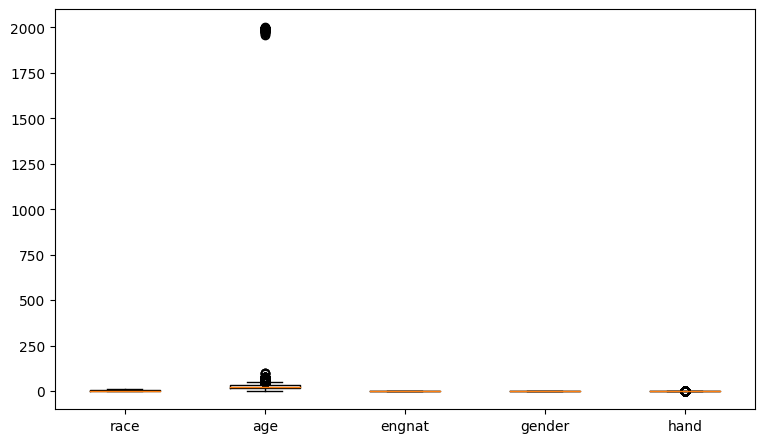

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize =(7, 4))

# Creando los ejes
ax = fig.add_axes([0, 0, 1, 1])

# etiquetas del eje x de datacolumns
ax.set_xticklabels(datacolumns[:5])

# Creando el gráfico
ax.boxplot(data[:, :5])

# mostrando el gráfico
plt.show()

## T1.A
- **En esta tarea, necesitas copiar el código anterior en la siguiente celda y adaptarlo para mostrar un diagrama de caja para todos los rasgos de personalidad (sin mostrar la información de metadatos).** <font color='blue'>(0.5 puntos)</font>
- Tenga en cuenta que las primeras cinco columnas son metadatos y lo restante ("datos[:, 5:]") son cuestionarios relacionados con la personalidad.


<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

<ipython-input-5-5065e2e7929f>:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datacolumns[5:])


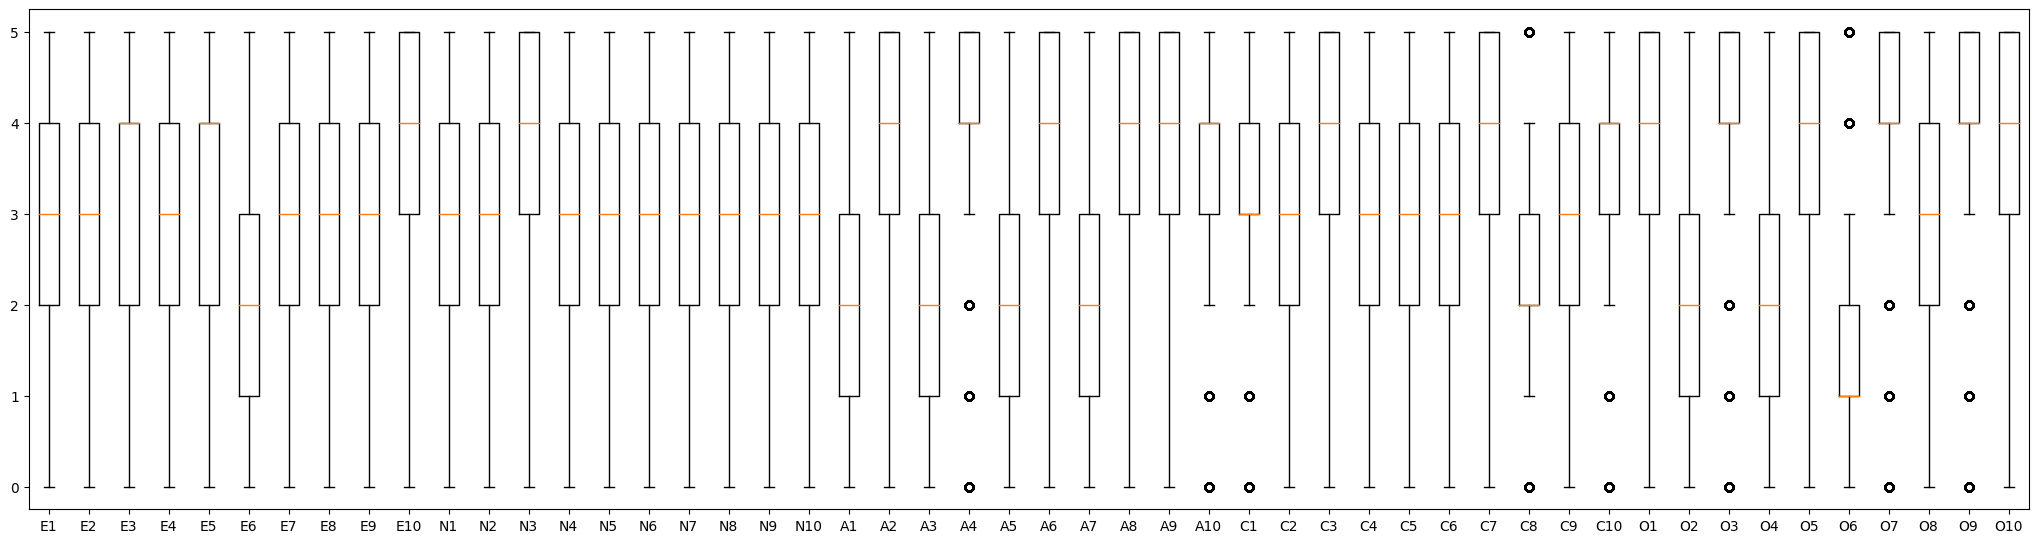

In [5]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# Copie el código anterior aquí (debajo de este comentario)
# y adáptelo para mostrar el diagrama de caja de los rasgos de personalidad.
fig = plt.figure(figsize =(20, 5))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xticklabels(datacolumns[5:])
ax.boxplot(data[:, 5:])
plt.show()

## Para practicar (*thresholding* y "limpieza de datos")
- El siguiente código crea una copia de los datos usando "data_cp = data"
- Luego, cambia todos los valores superiores a un umbral (100) a cero usando "data_cp[data_cp>100]=0".
 - Tenga en cuenta que esta estrategia de limpieza no debería funcionar para otros problemas o conjuntos de datos. Aquí conocemos el rango de nuestros datos y esta es la razón por la que podemos "limpiarlos" fácilmente cambiándolos a 0 valores fuera de dicho rango. Existen estrategias más inteligentes para tratar con valores atípicos (*outliers*), pero no se discutirán en esta práctica.
- Finalmente, generamos una visualización utilizando el mismo código que se proporcionó anteriormente. Después de limpiar los datos, podemos notar que la nueva visualización nos ayuda a interpretar mejor los datos.
- Siéntase libre para jugar con el valor de umbral y analizar los resultados (esta celda no se evaluará). Asegúrese de practicar con una copia de los datos para evitar cambiar los datos "originales".


<ipython-input-6-cca937c1f7f4>:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datacolumns[:5])


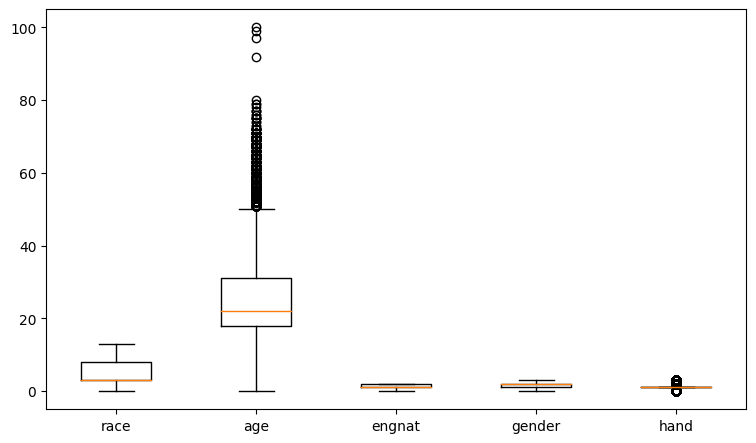

In [6]:
# creando una copia de nuestro conjunto de datos
data_cp = data.copy()

# cambiando todos los valores superiores a "100" a "0"
data_cp[data_cp>100]=0

fig = plt.figure(figsize =(7, 4))

# Creando los ejes
ax = fig.add_axes([0, 0, 1, 1])

# etiquetas del eje x de datacolumns
ax.set_xticklabels(datacolumns[:5])

# Creando el gráfico
ax.boxplot(data_cp[:, :5])

# mostrando el gráfico
plt.show()

# Histograma
- El siguiente código se usa para generar y visualizar los histogramas para cada pregunta en la personalidad de ***extroversion***.



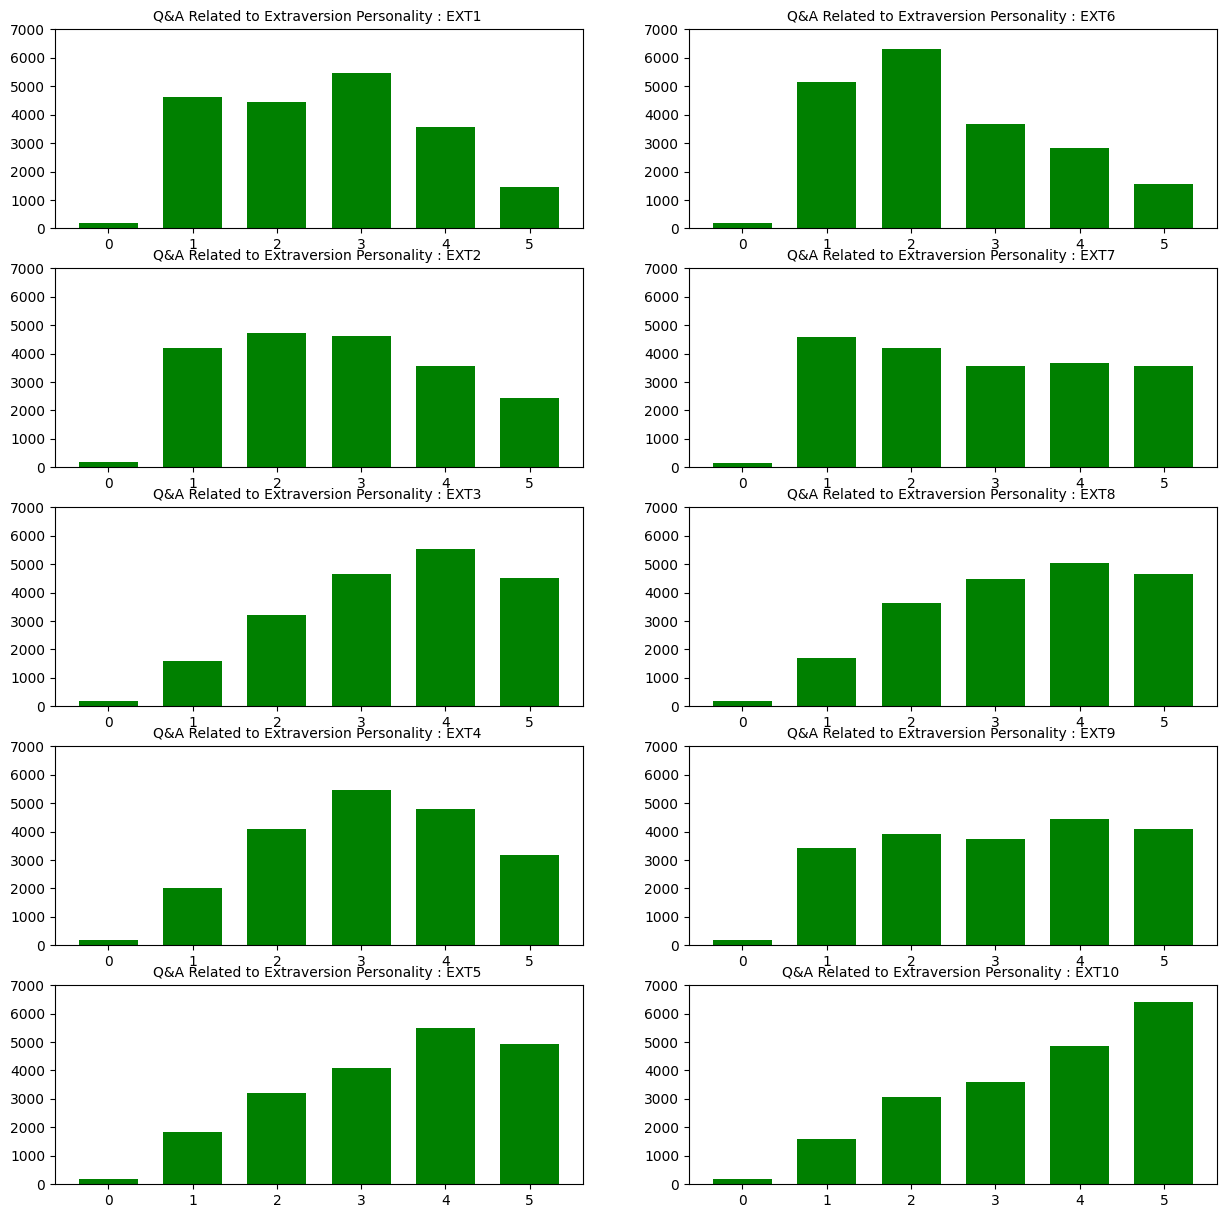

<Figure size 400x200 with 0 Axes>

In [7]:
fig, axs = plt.subplots(5, 2, figsize =(15, 15))

# lista de preguntas para la personalidad de extraversión
fft=['EXT1','EXT2','EXT3','EXT4','EXT5','EXT6','EXT7','EXT8','EXT9','EXT10']
n=0 # un contador para realizar un seguimiento de las preguntas
for f in fft:
    # "[n%5, n//5]" define el índice del subplot
    # "bins" define los rangos en los que se distribuyen los valores
    # ([0, 1, 2, 3, 4, 5, 6]) - aquí, el "-0.5" se usa para centrar las
    # etiquetas con las barras en el eje x
    # En "data[:, 5+n]", 5 es el índice de la primera pregunta de extraversión
    bins = np.arange(7) - 0.5
    axs[n%5, n//5].hist(data[:, 5+n], bins, rwidth=0.7, color='green')
    # Fijar el rango de valores mostrados en el eje Y
    axs[n%5, n//5].set_ylim(0, 7000)
    axs[n%5, n//5].set_title("Q&A Related to Extraversion Personality : {} ".format(f), fontsize = 10)
    n=n+1
plt.figure(figsize =(4, 2))
plt.tight_layout()
plt.show()

## T1.B
- **Copia el código anterior en la siguiente celda y adáptalo para visualizar el histograma de *openness*.** <font color='blue'>(0.5 puntos)</font>

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

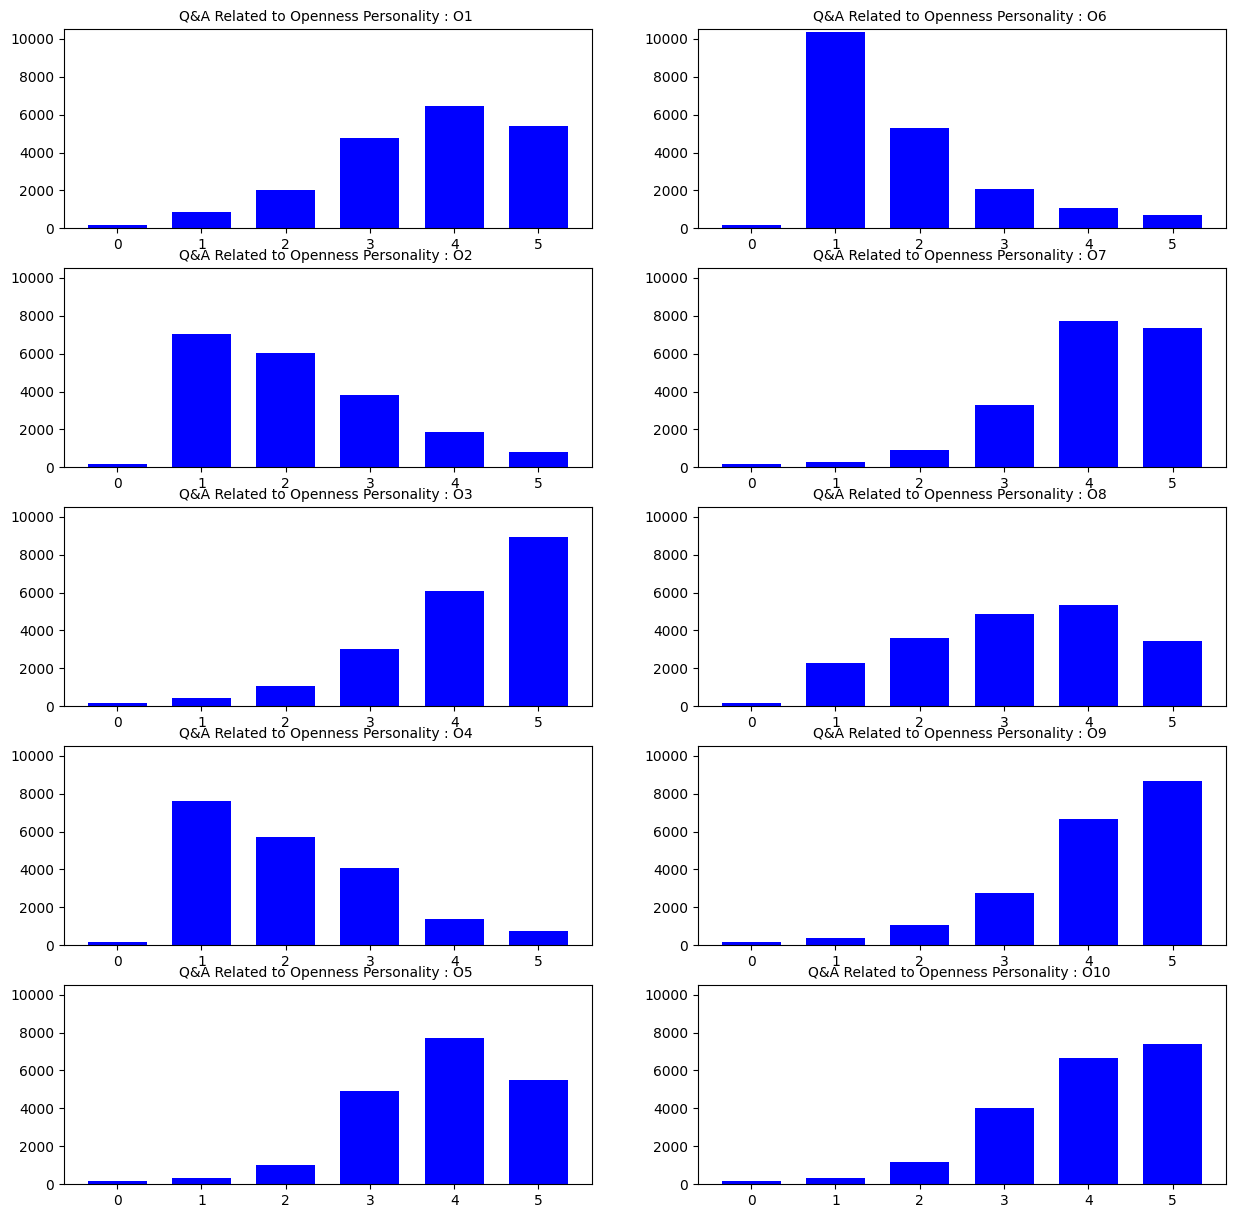

<Figure size 400x200 with 0 Axes>

In [8]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# Copie el código anterior aquí (debajo de este comentario)
# y adáptelo para mostrar histogramas de "openness"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Generar y visualizar los histogramas para cada pregunta en la personalidad de apertura (openness)
fig, axs = plt.subplots(5, 2, figsize=(15, 15))

# Lista de preguntas para la personalidad de apertura
openness_questions = ['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10']
n = 0 # un contador para realizar un seguimiento de las preguntas
for f in openness_questions:
    # "[n%5, n//5]" define el índice del subplot
    # "bins" define los rangos en los que se distribuyen los valores
    # ([0, 1, 2, 3, 4, 5, 6]) - aquí, el "-0.5" se usa para centrar las
    # etiquetas con las barras en el eje x
    # En "data[f]", f es la columna correspondiente a la pregunta de apertura
    bins = np.arange(7) - 0.5
    axs[n%5, n//5].hist(data[:, 45+n], bins, rwidth=0.7, color='blue')
    # Fijar el rango de valores mostrados en el eje Y
    axs[n%5, n//5].set_ylim(0, 10500)
    axs[n%5, n//5].set_title("Q&A Related to Openness Personality : {} ".format(f), fontsize=10)
    n = n + 1
plt.figure(figsize =(4, 2))
plt.tight_layout()
plt.show()


## T1.C

- Teniendo en cuenta los gráficos anteriores, conteste la siguiente pregunta.

- Las preguntas E6 y E10 del rasgo de extraversión tienen distribuciones diferentes. **¿Cómo se reflejan estas diferencias en los gráficos de histograma para las preguntas correspondientes?** También puedes basar tu respuesta con la ayuda del diagrama de caja (resuelto en T1.A) <font color='blue'>(0.5 puntos)</font>

<font color='red'> Las preguntas E6 y E10 tienen distribuciones diferentes. En la pregunta E10 se puede observar en el histograma que va aumentando progresivamente, pareciéndose a una escalera, con la mayoría de los participantes eligiendo 4 y 5. Por otro lado, en la pregunta E6 la mayoría de las respuestas se concentran en 1 y 2, disminuyendo progresivamente hacia 5, lo que indica una tendencia hacia valores bajos. Esto nos indica que los participantes se identifican más con los enunciados de E10. En el diagrama de caja podemos ver que la mediana de E10 es superior a la de E6, por lo tanto también la media lo sera.  </font>



## T1.D

- Teniendo en cuenta los gráficos anteriores, conteste la siguiente pregunta.

- Dado el rasgo de *Openness*, **¿qué pregunta tiene mayor varianza con respecto a sus respuestas (O1, O2, ..., O10)?** <font color='blue'>(1 punto)</font>
- *La varianza es una medida de dispersión. Es decir, es una medida de cuánto se separa un conjunto de números de su valor promedio (para proporcionar la respuesta exacta, aparte de la inspección visual, puedes consultar algunos ejemplos sobre cómo calcular la varianza usando python: https://numpy.org/doc/stable/reference/generated/numpy.var.html#numpy.var*

<font color='red'> Observando los gráficos de Openness, se puede intuir que las preguntas O1 Y O8 serán las que contengan mayor varianza en sus respuestas, pues tienen los valores más equilibrados mostrando una mayor dispersión de los resultados. En concreto la pregunta O8 tiene mayor equilibrio en cuanto a los valores de cada respuesta, posiblemente siendo la pregunta con mayor varianza. </font>

 <font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

In [9]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------


# Si las preguntas de Openness no están en columnas consecutivas, deberás ajustar los índices
# Aquí, por ejemplo, asumimos que las columnas de interés son las primeras 10 columnas de 'data'
openness_data = data[:, 45:54]

# Calcular la varianza para cada columna/pregunta
variances = np.var(openness_data, axis=0)

# Encontrar la pregunta con la mayor varianza
max_variance_index = np.argmax(variances)
question_with_max_variance = openness_questions[max_variance_index]

# Imprimir los resultados
print(f"Pregunta con mayor varianza en Openness: {question_with_max_variance}")
print(f"Valor de varianza: {variances[max_variance_index]}")

Pregunta con mayor varianza en Openness: O8
Valor de varianza: 1.6672276258468628


---
# **TAREA 2:** Preprocesamiento de datos
- Como se mencionó anteriormente, los datos tienen algo de ruido, valores faltantes (*missing values*) y valores atípicos (*outliers*), lo que resultó en una mala visualización de los metadatos en el diagrama de caja utilizado para la Tarea 1.
- Algunos valores de personalidad también tienen valores iguales a cero.
- Por lo tanto, debemos preprocesar y limpiar los datos para asegurarnos de que estén listos para ser utilizados por nuestros algoritmos de *Machine Learning*.


## T2.A
- Siendo más específico, tenemos valores ruidosos en la columna "age" (edad). La fuente del ruido es que se informa el año de nacimiento en lugar de la edad. Estos valores podrían corregirse restando 2019 (el año en que se recopiló el conjunto de datos) por el año de nacimiento informado. **Encuentre los valores por encima de 100 en la columna de edad y corríjalos. Luego, vuelva a visualizar el diagrama de caja en los metadatos como se ilustra en la Tarea 1.** <font color='blue'>(1.0 punto)</font>

 <font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

Datos que son >100:
[1997. 1995. 1994. 1997. 1994. 1994. 1992. 1988. 1990. 1999. 1997. 1992.
 1994. 1989. 1997. 1984. 1994. 1993. 1992. 1994. 1996. 1996. 1982. 1995.
 1991. 1998. 1992. 1961. 1989. 1989. 1986. 1976. 1993. 1986. 1991. 1977.
 2000. 1995. 1968. 1982. 1993. 1974. 1985. 1996. 1994. 1996. 1993. 1992.
 1992. 1990. 1992. 1991. 1982. 1998. 1989. 1989. 1976. 1996. 1982. 1995.
 1996. 1994. 1985. 1990. 1992. 1984. 1992. 1996. 1998. 1964. 1993. 1998.]
En que fila estan:
[  331   500   649   971  1044  1238  1384  1403  1497  1649  1684  2100
  2500  3002  3016  3678  3683  4502  4543  4791  5082  5145  5777  5932
  6219  6614  6965  7998  8140  8174  9415  9777  9916 10096 10134 10244
 10715 10720 10901 10934 10944 11755 12156 12354 12707 12846 12889 12963
 13125 13223 13403 13441 13602 14628 15535 15781 15855 16079 16259 16670
 16888 17041 17042 17059 17502 17823 18188 18523 18661 18730 18800 19614]


<ipython-input-10-c847e840a1a4>:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datacolumns[:5])


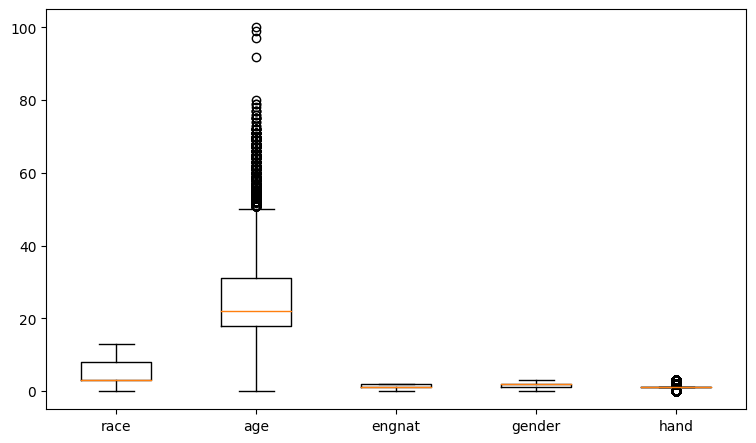

In [10]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

print('Datos que son >100:')
print(data[data[:, 1] > 100, 1])
print('En que fila estan:')
print(np.where(data[:, datacolumns.index('age')] > 100)[0])

# paso 1 (preprocesar sus datos)
data[:, 1] = np.where(data[:, 1] > 100, 2019 - data[:, 1], data[:, 1])

# paso 2 (visualizar los datos limpios)
fig = plt.figure(figsize =(7, 4))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xticklabels(datacolumns[:5])
ax.boxplot(data[:, :5])
plt.show()

# Al final, podrás crear una copia de los datos procesados, para utilizarla más adelante (en T2.B)
data_cp_T2A = data.copy()

## Llenando los valores faltantes
- Consideremos que los valores faltantes en este conjunto de datos aparecen como 0.
- En el siguiente código, los valores que faltan se reemplazan por la muestra más cercana en el conjunto de datos. Puedes consultar la documentación del método adoptado aquí: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html
- Curiosamente, las muestras donde 'age' = 0 no tienen el valor de edad reemplazado por otro valor, ya que la muestra más cercana parece ser otra muestra con 'age' = 0, lo que sugiere que este atributo tiene una fuerte influencia en la forma en que se calcula la distancia a otras muestras (en este caso). Esto se ilustra a continuación, cuando se muestra el número de valores faltantes para dos atributos ('race' y 'age', antes y después de usar esta estrategia).
- Luego, comparamos el resultado con los valores originales (cargados como "data_original") utilizando la función dada "L1", que calcula el error de diferencia absoluta media en cada columna.
- Tenga en cuenta que la versión modificada de los datos que estamos usando tiene algo de ruido incluido manualmente. Es por eso que estamos comparando los resultados con el conjunto original, para tener una idea de cuán efectiva es nuestra estrategia para lidiar con los datos faltantes.



In [11]:
# obteniendo el número de valores faltantes de los atributos 'x' e 'y'
# antes de completar los datos faltantes
x = 0 # race
y = 1 # age
counter_x = 0
counter_y = 0
for count, value in enumerate(data[:,x]):
  if(value==0):
    counter_x +=1
for count, value in enumerate(data[:,y]):
  if(value==0):
    counter_y +=1
print("numero de valores faltantes: 'race' = %d,  'age' = % d" % (counter_x,counter_y))

numero de valores faltantes: 'race' = 329,  'age' =  182


In [12]:
from sklearn.neighbors import KDTree

# Construyendo el modelo kd-tree
tree = KDTree(data, leaf_size=2)

# Estrayendo las 6 muestras más cercanas de todo el conjunto de datos
# Tenga en cuenta que la primera muestra más cercana es la propia muestra.
dist, ind = tree.query(data, k=6)

In [13]:
# Buscando índices con valores 0
ind_row, ind_col = np.where(data==0)

# Comprobando los valores 0 y reemplazándolos.
for i,j in zip(ind_row, ind_col):
    # Tenga en cuenta que la primera muestra más cercana es la propia muestra.
    # es por eso que no empezamos este bucle con cero
    for n in range(1, 6):
        # Asegurándonos de que la muestra más cercana no sea 0; de lo contrario, tomaremos la siguiente muestra más cercana
        if data[ind[i,n], j] != 0:
            data[i,j] = data[ind[i,n], j]
            break

def L1(X, Y, rows, cols):
    # Creando una variable "error" como un diccionario con una lista vacía por columna
    error = {}
    for i in range(X.shape[1]):
        error[i] = []

    # calculando el error de los valores faltantes
    for i,j in zip(rows, cols):
        error[j].append(np.abs(X[i,j] - Y[i,j]))

    # calculando el error promedio por columna
    for i in error.keys():
        if len(error[i]) > 0:
            error[i] = np.mean(error[i])

    return error

data_original, _ = load_data('data4_original.csv')
error_nearest = L1(data, data_original, ind_row, ind_col)
print("Error promedio al usar el reemplazo por el vecino más cercano: "+str(np.mean(list(error_nearest.values())[5:])))


# imprimiendo el error con los nombres de las columnas
txt = ""
for i in error_nearest.keys():
    txt += datacolumns[i] + "=" + ("{0:.2f}".format(error_nearest[i]) if type(error_nearest[i]) is not list else "[no missing value found]") + ", "
print(txt)

Error promedio al usar el reemplazo por el vecino más cercano: 1.1202759
race=2.73, age=37.77, engnat=0.58, gender=0.55, hand=0.48, E1=0.98, E2=1.11, E3=0.98, E4=1.05, E5=1.12, E6=0.89, E7=1.36, E8=1.32, E9=1.23, E10=1.42, N1=1.24, N2=1.17, N3=1.21, N4=1.12, N5=1.13, N6=1.18, N7=1.08, N8=1.01, N9=1.15, N10=1.11, A1=0.92, A2=1.12, A3=0.99, A4=0.99, A5=0.77, A6=1.39, A7=0.90, A8=1.14, A9=1.29, A10=1.07, C1=1.11, C2=1.46, C3=1.21, C4=1.03, C5=1.20, C6=1.32, C7=1.31, C8=0.86, C9=1.26, C10=1.08, O1=1.22, O2=0.96, O3=1.24, O4=0.88, O5=0.97, O6=0.82, O7=1.04, O8=1.14, O9=1.29, O10=1.17, 


In [14]:
# obteniendo el número de valores faltantes de los atributos 'x' e 'y'
# despues de completar los datos faltantes
x = 0 # race
y = 1 # age
counter_x = 0
counter_y = 0
for count, value in enumerate(data[:,x]):
  if(value==0):
    counter_x +=1
for count, value in enumerate(data[:,y]):
  if(value==0):
    counter_y +=1
print("numero de valores faltantes: 'race' = %d,  'age' = % d" % (counter_x,counter_y))

numero de valores faltantes: 'race' = 0,  'age' =  182


## T2.B

A continuación, en lugar de usar la muestra más cercana para reemplazar los valores faltantes, deberás:
- Primero, **calcular el valor promedio para cada columna y guardarlo usando alguna variable auxiliar**;
- Luego, **completar los valores faltantes de cada columna con el valor promedio obtenido para cada columna**;
- Finalmente, **comparar ambos métodos usando la función L1, de manera similar al código anterior**.

Tenga en cuenta que toda esta parte debe resolverse utilizando los datos limpios en el ejercicio anterior (T2.A).

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font> <font color='blue'>(2 puntos)</font>





In [15]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# paso 0 cargar los dados procesados en el ejercisio T2.A
data = data_cp_T2A.copy()

# paso 1 (calcular el valor promedio para cada columna y guardarlo usando alguna variable auxiliar)

import pandas as pd

df = pd.DataFrame(data)

mean_values = df.mean()
#print(mean_values)

# paso 2 (completar los valores faltantes de cada columna con el valor promedio almacenado de la columna respectiva)
ind_row, ind_col = np.where(data==0)

for i, j in zip(*np.where(data == 0)):
    data[i, j] = mean_values[j]

# paso 3 (comparar ambos métodos usando la función L1, de manera similar al código anterior)
def L1(X, Y, rows, cols):
    # Creando una variable "error" como un diccionario con una lista vacía por columna
    error = {}
    for i in range(X.shape[1]):
        error[i] = []

    # calculando el error de los valores faltantes
    for i,j in zip(rows, cols):
        error[j].append(np.abs(X[i,j] - Y[i,j]))

    # calculando el error promedio por columna
    for i in error.keys():
        if len(error[i]) > 0:
            error[i] = np.mean(error[i])

    return error

data_original, _ = load_data('data4_original.csv')
error_nearest_2B = L1(data, data_original, ind_row, ind_col)
print("Error promedio al usar el promedio de la columna: "+str(np.mean(list(error_nearest_2B.values())[5:])))


# imprimiendo el error con los nombres de las columnas
txt = ""
for i in error_nearest.keys():
    txt += datacolumns[i] + "=" + ("{0:.2f}".format(error_nearest_2B[i]) if type(error_nearest_2B[i]) is not list else "[no missing value found]") + ", "
print(txt)

Error promedio al usar el promedio de la columna: 1.0030644
race=4.24, age=19.84, engnat=0.72, gender=0.60, hand=0.54, E1=1.15, E2=1.12, E3=1.12, E4=1.03, E5=1.26, E6=1.05, E7=1.27, E8=1.07, E9=1.21, E10=1.16, N1=1.08, N2=1.02, N3=0.99, N4=1.08, N5=1.11, N6=1.21, N7=1.19, N8=1.14, N9=1.12, N10=1.17, A1=1.14, A2=0.80, A3=0.94, A4=0.78, A5=0.88, A6=0.94, A7=0.95, A8=0.82, A9=0.81, A10=0.91, C1=0.96, C2=1.17, C3=0.79, C4=1.07, C5=1.08, C6=1.21, C7=0.92, C8=0.94, C9=1.04, C10=0.79, O1=0.89, O2=1.01, O3=0.82, O4=0.88, O5=0.80, O6=0.89, O7=0.73, O8=1.15, O9=0.72, O10=0.81, 


## Ahora, no deberíamos tener ningún valor de edad = 0

In [16]:
# obteniendo el número de valores faltantes de los atributos 'x' e 'y'
# despues de completar los datos faltantes (usando la segunda estrategia)
x = 0 # race
y = 1 # age
counter_x = 0
counter_y = 0
for count, value in enumerate(data[:,x]):
  if(value==0):
    counter_x +=1
for count, value in enumerate(data[:,y]):
  if(value==0):
    counter_y +=1
print("numero de valores faltantes: 'race' = %d,  'age' = % d" % (counter_x,counter_y))

numero de valores faltantes: 'race' = 0,  'age' =  0


## T2.C
Con respecto a la Tarea 2.A y 2.B,
- **Si consideramos unicamente las columnas asociadas a las preguntas de personalidad (es decir, excluyendo las columnas de metadatos), ¿qué método (usado para completar los valores faltantes) obtiene un error promedio más bajo? Proporcione el valor de error promedio obtenido para cada caso.** <font color='blue'>(0.5 puntos)</font>
  
<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>



<font color='red'> El error mas bajo es el de usar el valor del promedio de la columna.


<font color='red'>Proporcione la solución (código) en la siguiente celda.

In [17]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# error promedio para cada caso (excluyendo las columnas de metadatos)



print("Error promedio al usar el reemplazo por el vecino más cercano: "+str(np.mean(list(error_nearest.values())[5:])))


print("Error promedio al usar el promedio de la columna: "+str(np.mean(list(error_nearest_2B.values())[5:])))



Error promedio al usar el reemplazo por el vecino más cercano: 1.1202759
Error promedio al usar el promedio de la columna: 1.0030644


## T2.D
- Cada columna del conjunto de datos tiene un rango de valores y un significado diferente. En la siguiente celda, **normalice los datos (que obtuvieron el error promedio más pequeño en la tarea anterior, T2.C) de modo que todos los valores aparezcan en el mismo rango ([0,...,1]). La normalización debe hacerse por columna.** <font color='blue'>(1 punto)</font>.
 - Sugerencia: puedes dividir cada columna por su valor máximo.

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>


In [18]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# Cargar los datos procesados en el ejercicio T2.A
data = data_cp_T2A.copy()

# Calcular el valor promedio para cada columna y guardar en una variable auxiliar
mean_values = np.mean(data, axis=0)

# Llenar los valores faltantes con los promedios de cada columna
ind_row, ind_col = np.where(data == 0)
for i, j in zip(ind_row, ind_col):
    data[i, j] = mean_values[j]

# Normalizar los datos por columna
max_values = np.max(data, axis=0)
normalized_data = data / max_values

# Verificar los resultados
print("Datos normalizados:")
print(normalized_data)

# Verificar que los valores estén en el rango [0, 1]
print("Rango de valores normalizados por columna:")
print(np.min(normalized_data, axis=0), np.max(normalized_data, axis=0))


Datos normalizados:
[[0.23076923 0.53       0.5        ... 0.4        1.         1.        ]
 [1.         0.46       0.5        ... 0.2        0.6        0.4       ]
 [0.07692308 0.14       1.         ... 1.         1.         1.        ]
 ...
 [0.3846154  0.16       1.         ... 1.         1.         1.        ]
 [0.9230769  0.16       0.5        ... 0.6        1.         1.        ]
 [0.23076923 0.35       0.5        ... 1.         1.         1.        ]]
Rango de valores normalizados por columna:
[0.07692308 0.13       0.5        0.33333334 0.33333334 0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0.2        0.2        0.2        0.2        0.2
 0.2        0

---
# **TAREA 3:** Análisis de correlación
- El siguiente bloque de código muestra la correlación por pares de todas las columnas. Como podemos ver, existen correlaciones positivas, negativas o nulas (alrededor de cero). La siguiente matriz muestra, por ejemplo, que la raza (*race*) no tiene correlación con la edad, pero sí con el inglés nativo (*engnat*), y cierta correlación negativa con con la pregunta "O8".




In [19]:
import pandas as pd

dataframe = pd.DataFrame(data = data, columns = datacolumns)
correlation = dataframe.corr()
correlation.style.background_gradient(cmap = 'jet')


,race,age,engnat,gender,hand,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
race,1.000000,-0.085868,0.212202,0.050799,-0.017892,0.018424,0.014248,0.041851,0.018830,0.022235,0.075518,-0.005957,-0.006607,0.021541,0.029815,-0.011941,0.038397,0.001564,0.045449,0.068318,0.045780,0.036093,0.036587,0.013328,-0.020458,0.114503,-0.009833,-0.030447,0.036679,0.020007,0.057913,0.027036,-0.003723,0.042212,0.041339,0.010106,-0.074280,-0.006013,-0.024665,0.106665,-0.015188,0.009022,0.008573,0.048634,-0.009571,-0.202924,0.141025,-0.063487,0.106414,-0.043130,0.041601,-0.077328,-0.202665,-0.068500,-0.068484
age,-0.085868,1.000000,-0.071088,-0.030867,-0.004381,0.018290,-0.043536,0.106384,-0.072920,0.129600,-0.115248,0.078757,-0.011930,-0.009998,-0.155715,-0.115431,-0.015181,-0.111842,0.051256,-0.076144,-0.098236,-0.203215,-0.159523,-0.141211,-0.110416,-0.153257,0.055223,-0.182928,0.093001,-0.056438,0.082572,-0.081320,0.067359,0.074891,0.136542,0.096142,-0.066573,0.022488,-0.215372,0.154229,-0.146751,0.106836,-0.252188,0.100433,0.136361,0.131199,-0.055327,-0.027620,-0.012988,0.104795,-0.013537,0.088920,0.015049,0.049774,0.036837
engnat,0.212202,-0.071088,1.000000,-0.081656,-0.067439,-0.029367,0.067335,-0.023079,0.053877,-0.044190,0.105140,-0.064852,-0.082822,0.060012,0.023798,-0.047240,-0.021969,0.001525,0.076246,0.115660,0.072713,0.072987,0.114405,-0.010489,0.061822,0.246742,-0.058375,-0.070295,-0.022313,0.059550,0.008234,0.094544,-0.123193,0.020212,0.021561,-0.044547,-0.042852,-0.009321,0.024392,0.091087,0.011795,-0.090738,0.101589,-0.043828,0.002287,-0.102191,0.054972,-0.013550,0.043369,-0.038348,0.002804,0.020736,-0.123534,-0.069354,-0.059723
gender,0.050799,-0.030867,-0.081656,1.000000,-0.006063,0.002604,-0.113883,0.017358,-0.057897,0.068796,-0.084777,0.033889,0.002643,-0.077219,-0.003765,0.198682,-0.148224,0.154349,-0.055983,0.063355,0.144526,0.106765,0.115273,0.101865,0.052788,-0.117799,0.105369,-0.104048,0.163093,-0.152918,0.140042,-0.132309,0.132654,0.153513,0.065576,0.010354,0.020992,0.006272,0.029415,0.030306,0.005292,0.018020,-0.054367,0.080653,-0.003186,-0.061848,0.083889,-0.008619,0.051040,-0.099401,0.007613,-0.062610,-0.081266,0.003407,-0.082985
hand,-0.017892,-0.004381,-0.067439,-0.006063,1.000000,0.000891,0.007520,-0.023102,0.016829,0.001594,0.007854,0.006446,0.021717,-0.016418,-0.005252,-0.006054,0.005707,-0.017893,-0.003900,-0.017947,-0.025542,0.002410,0.011689,0.001044,0.004537,0.004841,-0.015788,0.041021,-0.038230,0.014937,-0.033450,0.026941,0.001861,-0.018932,-0.008511,0.013700,0.001104,0.036087,0.015163,0.005477,-0.007355,0.011569,0.009519,-0.007506,0.010671,0.055318,-0.023051,0.051316,-0.013307,0.036476,-0.032528,0.028839,0.069540,0.006352,0.050142
E1,0.018424,0.018290,-0.029367,0.002604,0.000891,1.000000,-0.417129,0.469895,-0.480304,0.474158,-0.344582,0.583052,-0.364007,0.450975,-0.410450,-0.113191,0.150367,-0.118616,0.134711,-0.068841,-0.100290,-0.045473,-0.053568,-0.090219,-0.194877,-0.015357,0.269662,0.044957,0.086071,-0.107953,0.061469,-0.224519,0.147281,0.136906,0.311735,0.052050,0.036005,0.012147,-0.056383,0.085474,-0.009401,-0.031492,-0.040243,0.044281,0.048223,0.040279,-0.026847,0.071534,-0.005965,0.183357,-0.095125,0.082657,0.008141,-0.082665,0.162711
E2,0.014248,-0.043536,0.067335,-0.113883,0.007520,-0.417129,1.000000,-0.444004,0.523415,-0.534679,0.564941,-0.477333,0.371590,-0.363732,0.461515,0.059594,-0.030317,0.057142,-0.066407,0.042657,0.041471,0.036403,0.051970,0.044259,0.186061,0.120868,-0.271123,-0.036764,-0.111357,0.203953,-0.059411,0.297766,-0.148922,-0.140181,-0.242504,-0.012209,-0.044960,0.022722,0.043110,-0.023834,-0.006444,0.021054,0.075929,-0.031655,-0.021645,-0.055212,0.057196,-0.041361,0.035075,-0.128066,0.103806,-0.057624,-0.019593,0.063974,-0.139240
E3,0.041851,0.106384,-0.023079,0.017358,-0.023102,0.469895,-0.444004,1.000000,-0.476665,0.585792,-0.390942,0.574808,-0.319624,0.419608,-0.4709

## T3.A
- Dada la matriz de correlación calculada en la celda anterior...
- **Para cada metadato (las primeras 5 columnas: *race, age, engnat, gender, hand*), nombre las características más correlacionadas (correlaciones negativas y positivas) y proporcione los respectivos valores de correlación, siguiendo el ejemplo dado**. <font color='blue'>(1 punto)</font>
 - Proporcione el código utilizado para identificar las correlaciones negativas/positivas (mínimas/máximas). Puedes usar funciones como "min" y "max" para identificar fácilmente los valores de cada atributo.

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

- **race:** neg_corr <font color='blue'> (01 / -0.202924) </font>, pos_corr <font color='blue'> (engnat / 0.212202) </font>
- **age:** neg_corr <font color='red'> (C8 / -0.252188) </font>, pos_corr <font color='red'> (C5 / 0.154229) </font>
- **engnat:** neg_corr <font color='red'> (O8 / -0.123534) </font>, pos_corr <font color='red'> (A1 / 0.246742) </font>
- **gender:** neg_corr <font color='red'> (A5 / -0.152918) </font>, pos_corr <font color='red'> (N1 / 0.198682) </font>
- **hand:** neg_corr <font color='red'> (engnat / -0.067439) </font>, pos_corr <font color='red'> (O8 / 0.069540) </font>

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

In [20]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# encontrando las correlaciones positivas/negativas para cada atributo
def find_correlations(column_name):
    corr_values = correlation[column_name]
    # Excluir la correlación de la columna consigo misma
    corr_values = corr_values[corr_values.index != column_name]
    # Encontrar la correlación mínima (negativa) y máxima (positiva)
    min_corr = corr_values.min()
    max_corr = corr_values.max()
    # Encontrar los nombres de las columnas correspondientes
    min_corr_col = corr_values.idxmin()
    max_corr_col = corr_values.idxmax()
    return min_corr_col, min_corr, max_corr_col, max_corr

# Lista de metadatos a analizar
metadata = ['race', 'age', 'engnat', 'gender', 'hand']

# Diccionario para almacenar los resultados
correlation_results = {}

# Calcular las correlaciones para cada metadato
for meta in metadata:
    neg_corr_col, neg_corr, pos_corr_col, pos_corr = find_correlations(meta)
    correlation_results[meta] = {
        'neg_corr': (neg_corr_col, neg_corr),
        'pos_corr': (pos_corr_col, pos_corr)
    }

# Imprimir los resultados en el formato especificado
for meta, corr in correlation_results.items():
    neg_corr_col, neg_corr = corr['neg_corr']
    pos_corr_col, pos_corr = corr['pos_corr']
    print(f"{meta}: neg_corr ({neg_corr_col} / {neg_corr:.6f}) , pos_corr ({pos_corr_col} / {pos_corr:.6f})")

race: neg_corr (O1 / -0.202924) , pos_corr (engnat / 0.212202)
age: neg_corr (C8 / -0.252188) , pos_corr (C5 / 0.154229)
engnat: neg_corr (O8 / -0.123534) , pos_corr (A1 / 0.246742)
gender: neg_corr (A5 / -0.152918) , pos_corr (N1 / 0.198682)
hand: neg_corr (engnat / -0.067439) , pos_corr (O8 / 0.069540)


# Mejorando la visualización anterior
- Como habrás notado, la visualización anterior incluye valores autocorrelacionados (por ejemplo, "age" vs. "age") en la diagonal principal (con valor de correlacion = 1). Si los cambiamos a 0.0, aumentará la gama de colores de la matriz generada (al "ignorar" la diagonal principal), generando una visualización que puede ser más fácil de interpretar, como se ilustra a continuación. Como antes, el mapa de colores adoptado ("jet") muestra correlaciones positivas en colores cálidos (tonos de rojo) y correlación negativa en colores fríos (tonos de azul).


In [21]:
import pandas as pd

dataframe = pd.DataFrame(data = data, columns = datacolumns)
correlation = dataframe.corr()
# reemplazando los valores de la diagonal a 0.0
np.fill_diagonal(correlation.values, 0.0)
correlation.style.background_gradient(cmap = 'jet')

,race,age,engnat,gender,hand,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
race,0.000000,-0.085868,0.212202,0.050799,-0.017892,0.018424,0.014248,0.041851,0.018830,0.022235,0.075518,-0.005957,-0.006607,0.021541,0.029815,-0.011941,0.038397,0.001564,0.045449,0.068318,0.045780,0.036093,0.036587,0.013328,-0.020458,0.114503,-0.009833,-0.030447,0.036679,0.020007,0.057913,0.027036,-0.003723,0.042212,0.041339,0.010106,-0.074280,-0.006013,-0.024665,0.106665,-0.015188,0.009022,0.008573,0.048634,-0.009571,-0.202924,0.141025,-0.063487,0.106414,-0.043130,0.041601,-0.077328,-0.202665,-0.068500,-0.068484
age,-0.085868,0.000000,-0.071088,-0.030867,-0.004381,0.018290,-0.043536,0.106384,-0.072920,0.129600,-0.115248,0.078757,-0.011930,-0.009998,-0.155715,-0.115431,-0.015181,-0.111842,0.051256,-0.076144,-0.098236,-0.203215,-0.159523,-0.141211,-0.110416,-0.153257,0.055223,-0.182928,0.093001,-0.056438,0.082572,-0.081320,0.067359,0.074891,0.136542,0.096142,-0.066573,0.022488,-0.215372,0.154229,-0.146751,0.106836,-0.252188,0.100433,0.136361,0.131199,-0.055327,-0.027620,-0.012988,0.104795,-0.013537,0.088920,0.015049,0.049774,0.036837
engnat,0.212202,-0.071088,0.000000,-0.081656,-0.067439,-0.029367,0.067335,-0.023079,0.053877,-0.044190,0.105140,-0.064852,-0.082822,0.060012,0.023798,-0.047240,-0.021969,0.001525,0.076246,0.115660,0.072713,0.072987,0.114405,-0.010489,0.061822,0.246742,-0.058375,-0.070295,-0.022313,0.059550,0.008234,0.094544,-0.123193,0.020212,0.021561,-0.044547,-0.042852,-0.009321,0.024392,0.091087,0.011795,-0.090738,0.101589,-0.043828,0.002287,-0.102191,0.054972,-0.013550,0.043369,-0.038348,0.002804,0.020736,-0.123534,-0.069354,-0.059723
gender,0.050799,-0.030867,-0.081656,0.000000,-0.006063,0.002604,-0.113883,0.017358,-0.057897,0.068796,-0.084777,0.033889,0.002643,-0.077219,-0.003765,0.198682,-0.148224,0.154349,-0.055983,0.063355,0.144526,0.106765,0.115273,0.101865,0.052788,-0.117799,0.105369,-0.104048,0.163093,-0.152918,0.140042,-0.132309,0.132654,0.153513,0.065576,0.010354,0.020992,0.006272,0.029415,0.030306,0.005292,0.018020,-0.054367,0.080653,-0.003186,-0.061848,0.083889,-0.008619,0.051040,-0.099401,0.007613,-0.062610,-0.081266,0.003407,-0.082985
hand,-0.017892,-0.004381,-0.067439,-0.006063,0.000000,0.000891,0.007520,-0.023102,0.016829,0.001594,0.007854,0.006446,0.021717,-0.016418,-0.005252,-0.006054,0.005707,-0.017893,-0.003900,-0.017947,-0.025542,0.002410,0.011689,0.001044,0.004537,0.004841,-0.015788,0.041021,-0.038230,0.014937,-0.033450,0.026941,0.001861,-0.018932,-0.008511,0.013700,0.001104,0.036087,0.015163,0.005477,-0.007355,0.011569,0.009519,-0.007506,0.010671,0.055318,-0.023051,0.051316,-0.013307,0.036476,-0.032528,0.028839,0.069540,0.006352,0.050142
E1,0.018424,0.018290,-0.029367,0.002604,0.000891,0.000000,-0.417129,0.469895,-0.480304,0.474158,-0.344582,0.583052,-0.364007,0.450975,-0.410450,-0.113191,0.150367,-0.118616,0.134711,-0.068841,-0.100290,-0.045473,-0.053568,-0.090219,-0.194877,-0.015357,0.269662,0.044957,0.086071,-0.107953,0.061469,-0.224519,0.147281,0.136906,0.311735,0.052050,0.036005,0.012147,-0.056383,0.085474,-0.009401,-0.031492,-0.040243,0.044281,0.048223,0.040279,-0.026847,0.071534,-0.005965,0.183357,-0.095125,0.082657,0.008141,-0.082665,0.162711
E2,0.014248,-0.043536,0.067335,-0.113883,0.007520,-0.417129,0.000000,-0.444004,0.523415,-0.534679,0.564941,-0.477333,0.371590,-0.363732,0.461515,0.059594,-0.030317,0.057142,-0.066407,0.042657,0.041471,0.036403,0.051970,0.044259,0.186061,0.120868,-0.271123,-0.036764,-0.111357,0.203953,-0.059411,0.297766,-0.148922,-0.140181,-0.242504,-0.012209,-0.044960,0.022722,0.043110,-0.023834,-0.006444,0.021054,0.075929,-0.031655,-0.021645,-0.055212,0.057196,-0.041361,0.035075,-0.128066,0.103806,-0.057624,-0.019593,0.063974,-0.139240
E3,0.041851,0.106384,-0.023079,0.017358,-0.023102,0.469895,-0.444004,0.000000,-0.476665,0.585792,-0.390942,0.574808,-0.319624,0.419608,-0.4709

# **TAREA 4:** Aprendizaje no supervisado (*clustering*) y reducción de la dimensionalidad
En este ejercicio practicarás con técnicas no supervisadas para agrupar los datos y reducir la dimensionalidad, además de visualizar el resultado.
- En la siguiente celda, primero construimos y ajustamos un modelo PCA para reducir la dimensionalidad de 50 a 2 características (se ignoran las 5 primeras columnas asociadas a los metadatos). Lo hacemos con fines de visualización.
- Luego, usamos el método *kmeans* para agrupar los datos de personalidad usando las 50 características (es decir, sin reducir la dimensionalidad).
- Repetimos el método de *clustering* que varía el número de grupos de 2 a 9 y visualizamos los datos utilizando los puntos 2D calculados usando PCA. A cada punto de datos se le asigna un color relacionado con el grupo al que pertenece.
- Tenga en cuenta que los metadatos no se incluyeron en este análisis.

Puedes encontrar un código de ejemplo para este ejercicio [aquí](https://www.kaggle.com/code/khotijahs1/big-five-personality-test-clustering), en el capítulo 4 al final del documento.

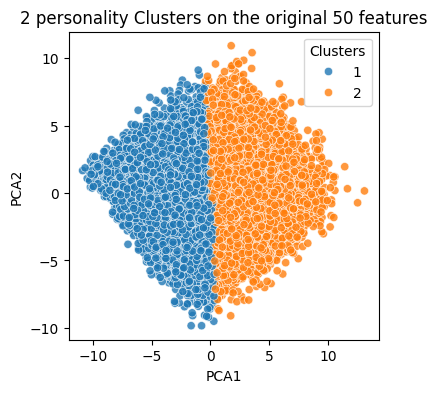

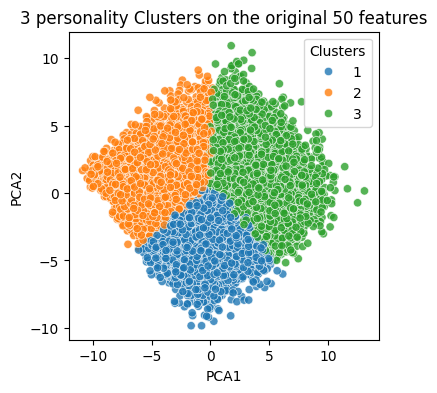

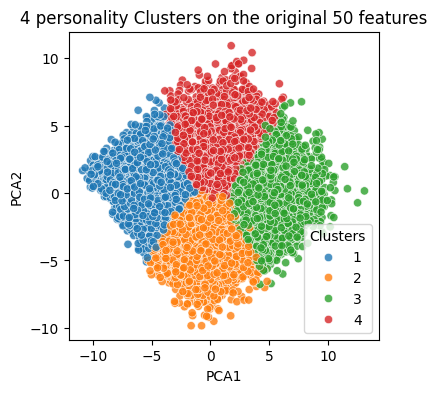

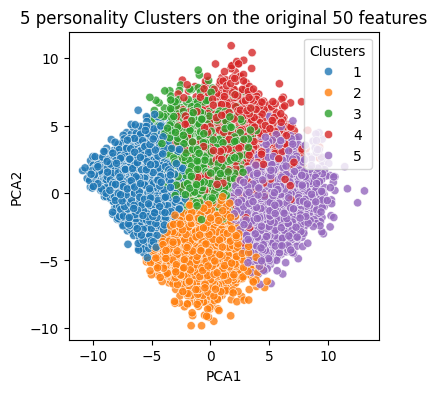

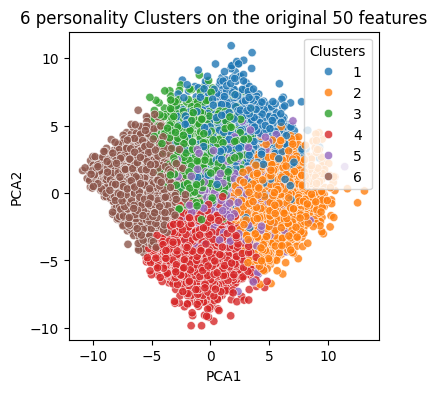

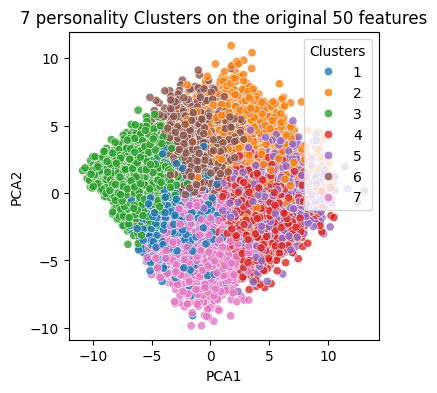

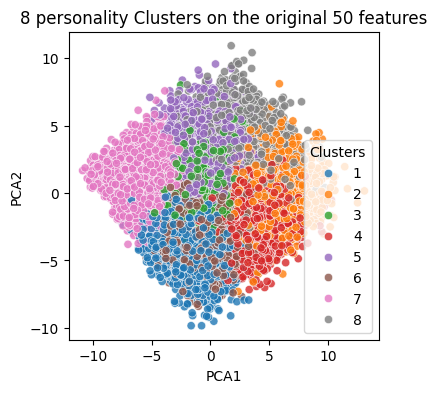

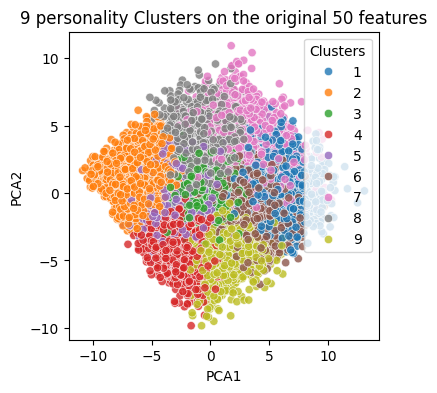

In [22]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# We need to convert numpy array to pandas data frame as needed by the given example code
# El ejemplo requiere que conviertamos un 'numpy array' a un 'data frame' de pandas
df_model = pd.DataFrame(data = data[:, 5:], columns = datacolumns[5:])

for k in range(2,10):
  # PCA
  pca = PCA(n_components=2)
  pca_fit = pca.fit_transform(df_model)
  df_pca = pd.DataFrame(data=pca_fit, columns=['PCA1', 'PCA2'])

  # kmeans
  kmeans = KMeans(n_clusters=k, n_init="auto")
  k_fit = kmeans.fit(df_model)

  # obteniendo los Clusters
  predictions = k_fit.labels_

  # agregando etiquetas de clúster
  df_pca['Clusters'] = predictions+1

  # Visualizando los clusters
  plt.figure(figsize=(4,4))
  sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Clusters', palette='tab10', alpha=0.8)
  plt.title(str(k) + ' personality Clusters on the original 50 features');
  plt.show()

## T4.A
- **Copie el código anterior en la siguiente celda y, en lugar de usar kmeans en los datos originales, hágalo en las características extraídas de PCA 2D.** <font color='blue'>(0.5 puntos)</font>

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

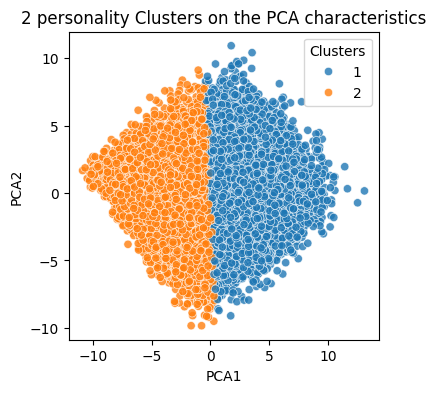

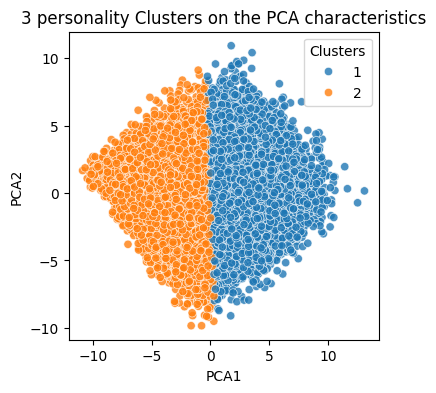

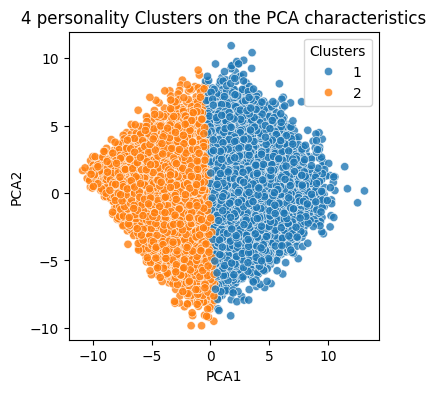

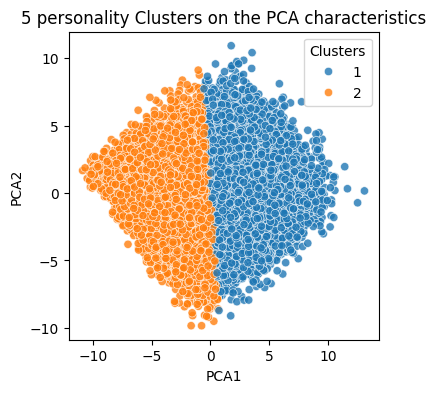

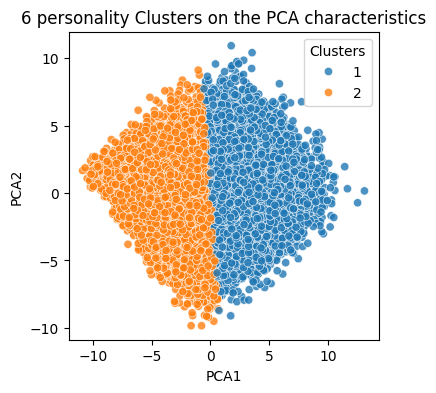

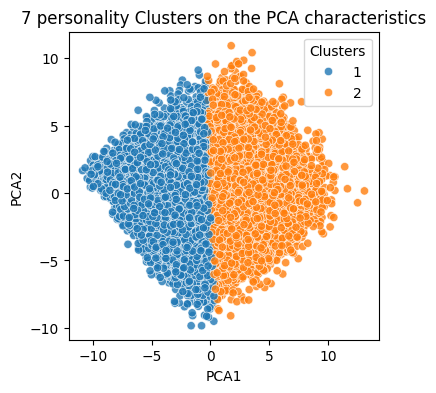

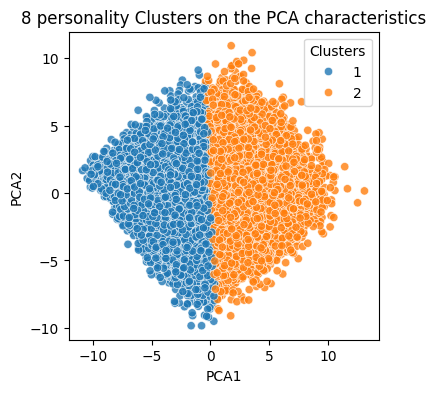

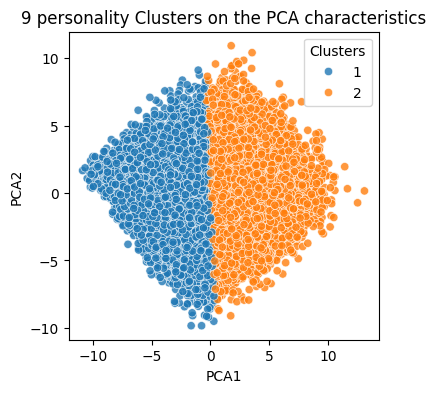

In [23]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# kmeans con características PCA 2D, usando k=2 a 9



df_model = pd.DataFrame(data = data[:, 5:], columns = datacolumns[5:])

for k in range(2,10):
  # PCA
  pca = PCA(n_components=2)
  pca_fit = pca.fit_transform(df_model)
  df_pca = pd.DataFrame(data=pca_fit, columns=['PCA1', 'PCA2'])

  # kmeans
  kmeans = KMeans(n_clusters=2, n_init="auto")
  k_fit = kmeans.fit(df_pca)

  # obteniendo los Clusters
  predictions = k_fit.labels_

  # agregando etiquetas de clúster
  df_pca['Clusters'] = predictions+1

  # Visualizando los clusters
  plt.figure(figsize=(4,4))
  sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Clusters', palette='tab10', alpha=0.8)
  plt.title(str(k) + ' personality Clusters on the PCA characteristics');
  plt.show()

# Introducción a las Tareas 4.B a 4.D
- *kmeans* es un algoritmo que agrupa datos por su proximidad en un espacio de N dimensiones. Sin embargo, la visualización de N datos dimensionales para N>3 no es posible. Es por eso que proyectamos los datos a dimensiones más bajas usando PCA. Aunque en los datos originales no hay superposición entre los grupos, pueden verse superpuestos en dimensiones más bajas.
- **Compare los nuevos gráficos que has generado (*clustering* con características 2D PCA) con los gráficos anteriores (*clustering* con datos de alta dimensión) y conteste las siguientes preguntas.**


## T4.B
- **¿Cómo se diferencian?** <font color='blue'>(0.5 puntos)</font>

<font color='red'> Los gráficos de clustering en alta dimensión muestran clusters bien separados y una asignación de puntos más precisa debido a la disponibilidad de todas las características de los datos. En contraste, los gráficos de clustering después de reducir la dimensionalidad con PCA a 2D pueden mostrar clusters más superpuestos debido a la pérdida de información. Esta proyección simplifica la visualización y permite identificar tendencias generales, pero podria no reflejar completamente las relaciones y distancias originales entre los puntos. </font>


# T4.C
- **¿Qué características son mejores para el *clustering*, 2D PCA o de alta dimensión?** <font color='blue'>(0.5 puntos)</font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): Para una comprensión profunda y precisa los datos de alta dimensión son preferibles, sin embargo, puede ser difícil visualizar e interpretar en dimensiones más allá de 4. Para la exploración inicial, el descubrimiento de patrones y la comunicación visual, PCA 2D puede ser más efectivo.
 </font>




# T4.D
- **¿Es la visualización 2D una forma confiable de asegurar la calidad del agrupamiento?**  <font color='blue'>(0.5 puntos)</font>

<font color='red'> No sería la forma más confiable al momento de asegurar la calidad del agrupamiento. Al tener solo dos dimensiones, es probable que se pierda información relevante, aunque no todo es negativo. En una visualización 2D ayuda a tener una idea rápida de la estructura general y detectar anomalías.
    </font>